# Data exploration (images only, without lables)

## What this notebook covers
Image-level EDA of the CT scan dataset: dataset overview (2000 train / 500 test, all 256×256 grayscale), missing-value check, grayscale intensity distributions, scanner-bias clustering (K-means), feature correlations, and organ-label frequency analysis from annotated_labels.json (image-level multi-label presence).


## Dataset overview for PNG image folder
Provide a high-level overview of the dataset. This should include the source of the dataset, the number of samples, the number of features, and example showing the structure of the dataset.

===== DATASET OVERVIEW =====
Dataset location: /workspaces/AnatomicStructuresSegmentation/1_DatasetCharacteristics/data/train-images/train-images
Number of samples (images): 2000

Typical image dimensions:
{'width': 256, 'height': 256}
Approx. number of features per image: 65536

Color modes:
mode
L    2000
Name: count, dtype: int64

First rows of dataset structure:


,filename,width,height,channels,mode,estimated_features
0,357.png,256,256,1,L,65536
1,710.png,256,256,1,L,65536
2,1893.png,256,256,1,L,65536
3,629.png,256,256,1,L,65536
4,457.png,256,256,1,L,65536


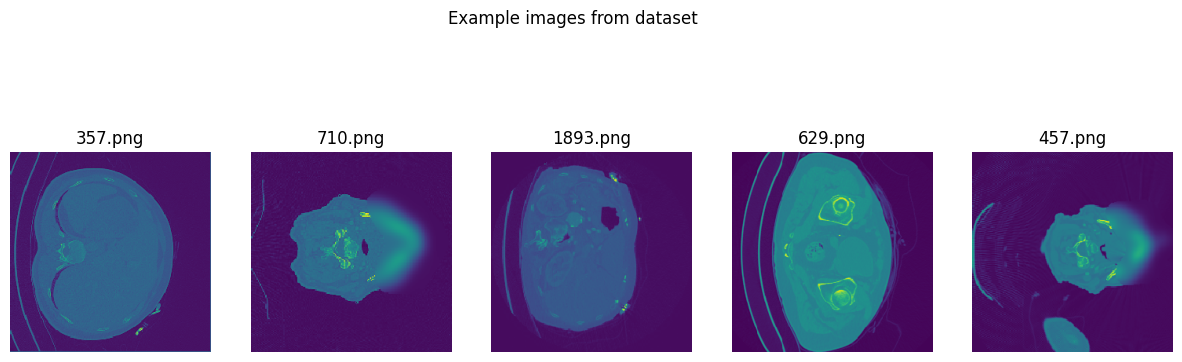

In [21]:
import os
from pathlib import Path
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------
# Dataset path (relative to notebook location)
# ----------------------------------------------------
dataset_path = Path("data/train-images/train-images")

# Collect PNG files
image_files = list(dataset_path.glob("*.png"))

# ----------------------------------------------------
# Basic statistics
# ----------------------------------------------------
num_samples = len(image_files)

info = []

for img_path in image_files:
    try:
        with Image.open(img_path) as img:
            width, height = img.size
            mode = img.mode      # RGB, RGBA, L, etc.

            info.append({
                "filename": img_path.name,
                "width": width,
                "height": height,
                "channels": len(img.getbands()),
                "mode": mode
            })

    except Exception as e:
        print(f"Could not load {img_path}: {e}")

df = pd.DataFrame(info)

# Estimate "features"
# Features = width × height × channels
if not df.empty:
    df["estimated_features"] = (
        df["width"] *
        df["height"] *
        df["channels"]
    )

# ----------------------------------------------------
# Print dataset overview
# ----------------------------------------------------
print("===== DATASET OVERVIEW =====")
print(f"Dataset location: {dataset_path.resolve()}")
print(f"Number of samples (images): {num_samples}")

if not df.empty:
    print("\nTypical image dimensions:")
    print(df[["width", "height"]].mode().iloc[0].to_dict())

    print(
        "Approx. number of features per image:",
        int(df["estimated_features"].median())
    )

    print("\nColor modes:")
    print(df["mode"].value_counts())

print("\nFirst rows of dataset structure:")
display(df.head())

# ----------------------------------------------------
# Show example images
# ----------------------------------------------------
n_examples = min(5, num_samples)

fig, axes = plt.subplots(1, n_examples, figsize=(15,5))

if n_examples == 1:
    axes = [axes]

for ax, img_path in zip(axes, image_files[:n_examples]):
    img = Image.open(img_path)

    ax.imshow(img)
    ax.set_title(img_path.name[:15])
    ax.axis("off")

plt.suptitle("Example images from dataset")
plt.show()

## Handling Missing Values

Identify any missing values in the dataset, and describe your approach to handle them if there are any. If there are no missing values simply indicate that there are none.

In [25]:
from pathlib import Path
from PIL import Image, UnidentifiedImageError
import pandas as pd

# Path to dataset
dataset_path = Path("data/train-images/train-images")

image_files = list(dataset_path.glob("*.png"))

missing_or_corrupt = []
valid_images = []

for img_path in image_files:
    try:
        with Image.open(img_path) as img:
            img.verify()  # checks if image is corrupted

        # Re-open (verify() closes file)
        with Image.open(img_path) as img:
            width, height = img.size

        valid_images.append(img_path.name)

    except (UnidentifiedImageError, OSError, SyntaxError) as e:
        missing_or_corrupt.append(img_path.name)

# -----------------------------
# Summary
# -----------------------------
print("===== MISSING / CORRUPT DATA CHECK =====")
print(f"Total images found: {len(image_files)}")
print(f"Valid images: {len(valid_images)}")
print(f"Corrupt/unreadable images: {len(missing_or_corrupt)}")

if missing_or_corrupt:
    print("\nExamples of problematic files:")
    print(missing_or_corrupt[:10])
else:
    print("\nNo missing or corrupt images found.")

===== MISSING / CORRUPT DATA CHECK =====
Total images found: 2000
Valid images: 2000
Corrupt/unreadable images: 0

No missing or corrupt images found.


## Feature Distributions
Plot the distribution of various features and target variables. Comment on the skewness, outliers, or any other observations.

In [26]:
from pathlib import Path
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

dataset_path = Path("data/train-images/train-images")
image_files = list(dataset_path.glob("*.png"))

data = []

for img_path in image_files:
    try:
        with Image.open(img_path) as img:
            width, height = img.size
            channels = len(img.getbands())
            
            data.append({
                "width": width,
                "height": height,
                "aspect_ratio": width / height,
                "channels": channels
            })
    except:
        continue

df = pd.DataFrame(data)

print("===== FEATURE SUMMARY =====")
display(df.describe())

===== FEATURE SUMMARY =====


,width,height,aspect_ratio,channels
count,2000.0,2000.0,2000.0,2000.0
mean,256.0,256.0,1.0,1.0
std,0.0,0.0,0.0,0.0
min,256.0,256.0,1.0,1.0
25%,256.0,256.0,1.0,1.0
50%,256.0,256.0,1.0,1.0
75%,256.0,256.0,1.0,1.0
max,256.0,256.0,1.0,1.0


### Verify grayscale structure

In [27]:
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd

dataset_path = Path("data/train-images/train-images")
image_files = list(dataset_path.glob("*.png"))

info = []

for img_path in image_files:
    with Image.open(img_path) as img:
        mode = img.mode  # 'L' = grayscale
        
        arr = np.array(img)
        
        info.append({
            "filename": img_path.name,
            "mode": mode,
            "mean_intensity": arr.mean(),
            "std_intensity": arr.std(),
            "min_intensity": arr.min(),
            "max_intensity": arr.max()
        })

df = pd.DataFrame(info)

print("===== IMAGE COLOR MODE CHECK =====")
print(df["mode"].value_counts())
display(df.head())

===== IMAGE COLOR MODE CHECK =====
mode
L    2000
Name: count, dtype: int64


,filename,mode,mean_intensity,std_intensity,min_intensity,max_intensity
0,357.png,L,46.940643,34.180665,0,255
1,710.png,L,36.099442,38.590281,4,255
2,1893.png,L,33.887329,30.423443,0,255
3,629.png,L,71.324966,54.278217,13,255
4,457.png,L,37.655075,39.906118,8,255


All images are stored in grayscale format (mode = ‘L’), meaning each pixel represents intensity values ranging from black (0) to white (255). No RGB channels are present.

 ### Distribution of Greytones (Intensity Statistics) Image vs. Image

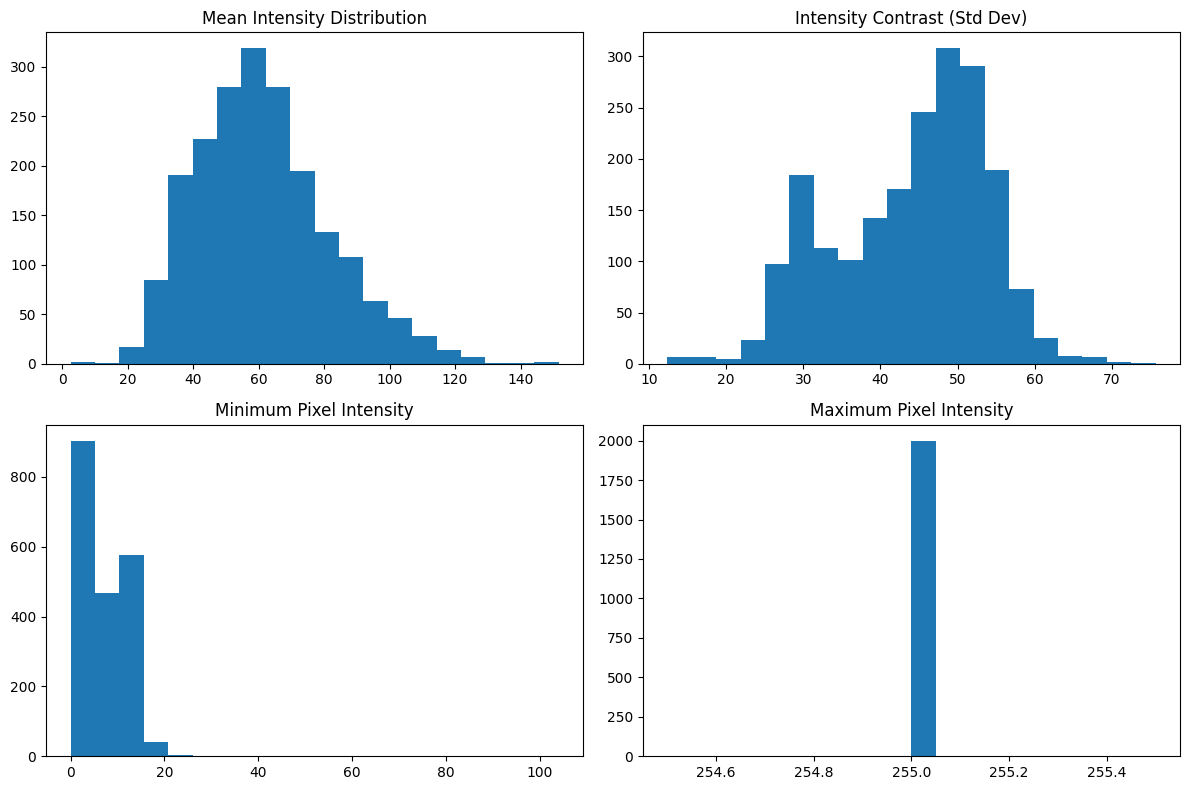

In [28]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Mean intensity distribution
axs[0, 0].hist(df["mean_intensity"], bins=20)
axs[0, 0].set_title("Mean Intensity Distribution")

# Standard deviation (contrast)
axs[0, 1].hist(df["std_intensity"], bins=20)
axs[0, 1].set_title("Intensity Contrast (Std Dev)")

# Min intensity
axs[1, 0].hist(df["min_intensity"], bins=20)
axs[1, 0].set_title("Minimum Pixel Intensity")

# Max intensity
axs[1, 1].hist(df["max_intensity"], bins=20)
axs[1, 1].set_title("Maximum Pixel Intensity")

plt.tight_layout()
plt.show()

1. Brightness distribution
peak near 0 → dark dataset
peak near 255 → bright dataset
centered peak → balanced lighting

The dataset shows a strong concentration around low-intensity values, which is expected due to the nature of CT scans.

2. Contrast (std deviation)
low std → flat / low-contrast images
high std → strong edges / detailed structure

A wide spread in standard deviation suggests varying levels of contrast across images.

3. Outliers
Look for:
extremely bright or dark images
near-constant images (std ≈ 0)

Example:
“A few images exhibit unusually low variance, indicating nearly uniform intensity regions.”

### Brightness vs contrast per image
- dark + low contrast images
- bright + high contrast images
- clusters/outliers

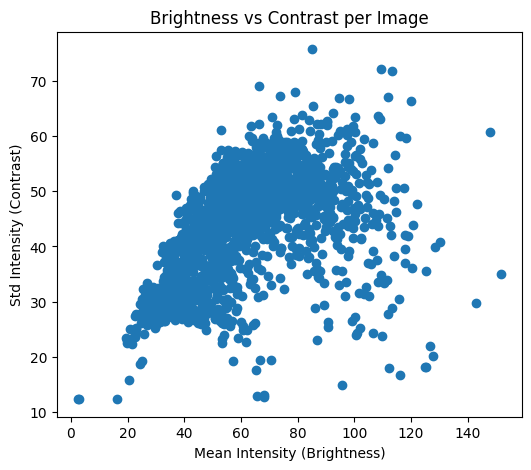

In [29]:
plt.figure(figsize=(6,5))
plt.scatter(df["mean_intensity"], df["std_intensity"])
plt.xlabel("Mean Intensity (Brightness)")
plt.ylabel("Std Intensity (Contrast)")
plt.title("Brightness vs Contrast per Image")
plt.show()

### Global Grey Tone Distribution (All Pixels)

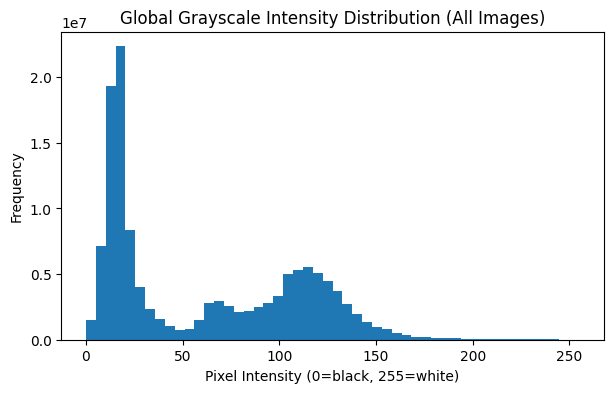

In [30]:
all_pixels = []

for img_path in image_files:
    with Image.open(img_path) as img:
        arr = np.array(img)
        all_pixels.append(arr.ravel())

all_pixels = np.concatenate(all_pixels)

plt.figure(figsize=(7,4))
plt.hist(all_pixels, bins=50)
plt.title("Global Grayscale Intensity Distribution (All Images)")
plt.xlabel("Pixel Intensity (0=black, 255=white)")
plt.ylabel("Frequency")
plt.show()

This shows the actual grayscale “shape” of the dataset.

## Possible Biases
Investigate the dataset for any biases that could affect the model’s performance and fairness (e.g., class imbalance, historical biases).

Since the dataset consists of CT images, potential biases were investigated through image-level statistics including intensity distribution, resolution variance, and clustering behavior. No explicit labels or demographic metadata were available; therefore, bias analysis focused on acquisition-related variability.

In CT imaging, bias usually comes from:

- Class imbalance (if labels exist)
e.g. “healthy vs diseased”
one class dominates → model becomes biased
- Scanner / hospital bias (VERY common in CT)
different machines produce different:
intensity distributions
noise levels
resolutions
- Patient demographic bias (if metadata exists)
age, gender, etc.
- Acquisition bias
slice thickness differences
contrast vs non-contrast CT
different protocols
- Technical bias (image-level)
resolution differences
brightness/contrast shifts
artifacts (motion, noise)

### Image-level distribution bias

In [31]:
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path

dataset_path = Path("data/train-images/train-images")
image_files = list(dataset_path.glob("*.png"))

rows = []

for img_path in image_files:
    with Image.open(img_path) as img:
        arr = np.array(img)

        rows.append({
            "file": img_path.name,
            "width": img.size[0],
            "height": img.size[1],
            "mean_intensity": arr.mean(),
            "std_intensity": arr.std()
        })

df = pd.DataFrame(rows)

df.describe()

,width,height,mean_intensity,std_intensity
count,2000.0,2000.0,2000.000000,2000.000000
mean,256.0,256.0,61.206421,43.905966
std,0.0,0.0,20.534448,9.878447
min,256.0,256.0,2.524918,12.372523
25%,256.0,256.0,46.256710,36.465472
50%,256.0,256.0,59.151619,45.929980
75%,256.0,256.0,72.606873,51.214447
max,256.0,256.0,151.645920,75.666356


- large spread in width/height → resizing bias needed
- multi-modal intensity distribution → scanner bias
- high std variation → inconsistent imaging conditions

### Detect “scanner-style clusters” (hidden bias)

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = df[["mean_intensity", "std_intensity", "width", "height"]]

X = StandardScaler().fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X)

df["cluster"].value_counts()

cluster
0    965
1    632
2    403
Name: count, dtype: int64

If clusters form:
- Cluster 1 = dark low-contrast CTs
- Cluster 2 = bright high-noise CTs
- Cluster 3 = high-res scans
This indicates hidden acquisition bias

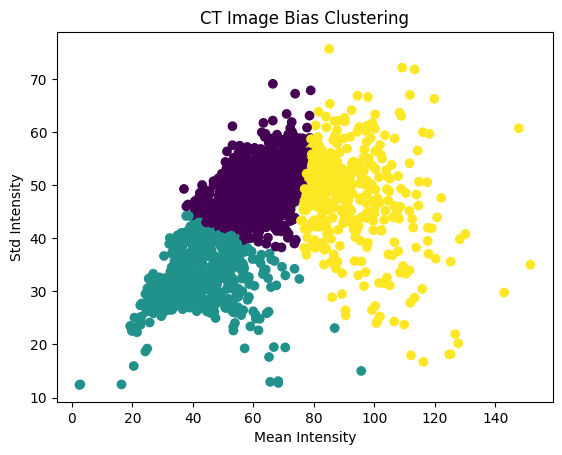

In [33]:
import matplotlib.pyplot as plt

plt.scatter(df["mean_intensity"], df["std_intensity"], c=df["cluster"])
plt.xlabel("Mean Intensity")
plt.ylabel("Std Intensity")
plt.title("CT Image Bias Clustering")
plt.show()

- If clusters are separated → dataset **is not** homogeneous
- If one cluster dominates → strong bias toward one acquisition style

## Correlations
Explore correlations between features and the target variable, as well as among features themselves.

### Feature–Feature Correlation
This checks relationships like brightness vs contrast, resolution vs intensity, etc.

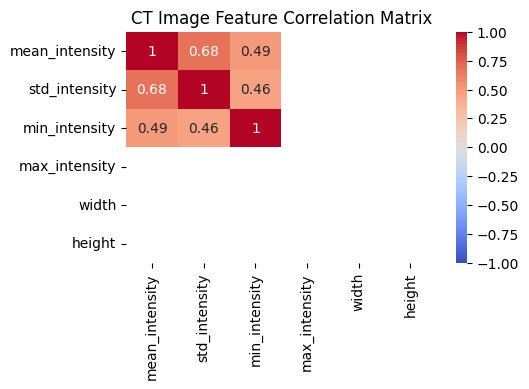

,filename,mean_intensity,std_intensity,min_intensity,max_intensity,width,height
0,357.png,73.308990,57.934896,0,255,256,256
1,457.png,44.710663,34.854758,1,255,256,256
2,295.png,115.879684,52.650405,16,255,256,256
3,120.png,23.154114,28.250794,4,255,256,256
4,271.png,56.803574,38.020126,0,255,256,256


In [ ]:
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Load dataset
# -----------------------------
dataset_path = Path("data/train-images/train-images")
image_files = list(dataset_path.glob("*.png"))

# -----------------------------
# Extract features safely
# -----------------------------
rows = []

for img_path in image_files:
    with Image.open(img_path) as img:
        arr = np.array(img)

        rows.append({
            "filename": img_path.name,
            "mean_intensity": arr.mean(),
            "std_intensity": arr.std(),
            "min_intensity": arr.min(),
            "max_intensity": arr.max(),
            "width": img.size[0],
            "height": img.size[1]
        })

df = pd.DataFrame(rows)

# -----------------------------
# Correlation matrix (safe)
# -----------------------------
corr_df = df[[
    "mean_intensity",
    "std_intensity",
    "min_intensity",
    "max_intensity",
    "width",
    "height"
]]

corr_matrix = corr_df.corr()

# -----------------------------
# Plot heatmap
# -----------------------------
plt.figure(figsize=(5,3))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("CT Image Feature Correlation Matrix")
plt.show()

# -----------------------------
# Optional: show dataframe preview
# -----------------------------
display(df.head())

Look for:

- **Strong positive correlation (+1)**
width ↔ height → images scaled together
min ↔ max → consistent intensity range
- **Weak correlation (~0)**
intensity vs size → independent properties
- **Strong negative correlation (-1)**
rare in image metadata, but possible if preprocessing is inconsistent

“The correlation matrix shows relationships between intensity-based and structural features. Weak correlations suggest that brightness and resolution are independent properties of the dataset, while strong correlations between width and height indicate consistent image scaling.”

# Data exploration (images with lables)

## Load and inspect annotated_labels.json

You now have three label states per organ per image:
- Explicitly present in annotated_labels.json → organ is definitely present
- Explicitly marked absent → organ is definitely NOT present
- Missing from JSON → unknown (unlabeled) OR could be present OR absent

In [12]:
import json
from pathlib import Path

json_path = Path("data/annotated_labels.json")

with open(json_path, "r") as f:
    annotations = json.load(f)

print("Number of scans:", len(annotations))

Number of scans: 2000


In [13]:
import json

with open("data/annotated_labels.json", "r") as f:
    annotations = json.load(f)

print(type(annotations))
print(annotations[:2])

<class 'list'>
[[2, 4, 8, 10, 11, 12, 13, 14, 15, 18, 20, 22, 23, 24, 28, 30, 31, 32, 36, 44, 46, 47, 49, 50, 52, 53, 54], [4, 6, 10, 11, 12, 13, 15, 17, 19, 21, 23, 24, 25, 26, 27, 29, 33, 37, 42, 45, 46, 47, 48, 49, 51, 53, 54]]


### Convert into dataframe

In [14]:
print("TYPE:", type(annotations))
print("FIRST ITEM TYPE:", type(annotations[0]))
print("FIRST ITEM VALUE:\n", annotations[0])

TYPE: <class 'list'>
FIRST ITEM TYPE: <class 'list'>
FIRST ITEM VALUE:
 [2, 4, 8, 10, 11, 12, 13, 14, 15, 18, 20, 22, 23, 24, 28, 30, 31, 32, 36, 44, 46, 47, 49, 50, 52, 53, 54]


## Understand the JSON Structure



In [15]:
import json

with open("data/annotated_labels.json", "r") as f:
    annotations = json.load(f)

print("Root type:", type(annotations).__name__)
print("Number of rows:", len(annotations))
print("Type of first row:", type(annotations[0]).__name__)
print("\nFirst row (likely header):")
print(annotations[0])
print("\nSecond row (likely first data entry):")
print(annotations[1])
print("\nThird row:")
print(annotations[2])

Root type: list
Number of rows: 2000
Type of first row: list

First row (likely header):
[2, 4, 8, 10, 11, 12, 13, 14, 15, 18, 20, 22, 23, 24, 28, 30, 31, 32, 36, 44, 46, 47, 49, 50, 52, 53, 54]

Second row (likely first data entry):
[4, 6, 10, 11, 12, 13, 15, 17, 19, 21, 23, 24, 25, 26, 27, 29, 33, 37, 42, 45, 46, 47, 48, 49, 51, 53, 54]

Third row:
[2, 3, 6, 7, 8, 9, 11, 12, 16, 18, 21, 22, 23, 24, 28, 31, 32, 33, 34, 36, 38, 39, 42, 44, 49, 50, 54]


## Convert to DataFrame and Link Annotations to Images  
Each annotation entry should reference one of the PNG files in `data/test-images/test-images/`. We identify which key holds the filename or image ID, then cross-check it against the actual image files to see how many images have annotations and how many are unmatched.

In [16]:
import pandas as pd

header = annotations[0]
data   = annotations[1:]

df_raw = pd.DataFrame(data, columns=header)

print("Shape:", df_raw.shape)
print("\nColumns:", df_raw.columns.tolist())
print("\nData types:")
print(df_raw.dtypes)
display(df_raw.head(5))

Shape: (1999, 27)

Columns: [2, 4, 8, 10, 11, 12, 13, 14, 15, 18, 20, 22, 23, 24, 28, 30, 31, 32, 36, 44, 46, 47, 49, 50, 52, 53, 54]

Data types:
2     float64
4     float64
8     float64
10    float64
11    float64
12    float64
13    float64
14    float64
15    float64
18    float64
20    float64
22    float64
23    float64
24    float64
28    float64
30    float64
31    float64
32    float64
36    float64
44    float64
46    float64
47    float64
49    float64
50    float64
52    float64
53    float64
54    float64
dtype: object


,2,4,8,10,11,12,13,14,15,18,...,32,36,44,46,47,49,50,52,53,54
0,4.0,6.0,10.0,11.0,12.0,13.0,15.0,17.0,19.0,21.0,...,37.0,42.0,45.0,46.0,47.0,48.0,49.0,51.0,53.0,54.0
1,2.0,3.0,6.0,7.0,8.0,9.0,11.0,12.0,16.0,18.0,...,33.0,34.0,36.0,38.0,39.0,42.0,44.0,49.0,50.0,54.0
2,1.0,6.0,7.0,12.0,16.0,17.0,20.0,21.0,23.0,24.0,...,36.0,38.0,41.0,43.0,47.0,48.0,51.0,52.0,53.0,54.0
3,4.0,5.0,9.0,11.0,12.0,13.0,15.0,17.0,20.0,22.0,...,39.0,40.0,41.0,43.0,44.0,45.0,48.0,50.0,52.0,54.0
4,3.0,5.0,6.0,10.0,11.0,13.0,14.0,15.0,18.0,20.0,...,34.0,37.0,38.0,41.0,42.0,46.0,49.0,50.0,51.0,53.0


## Correct Interpretation - Sparse Multi-Label Encoding

In [17]:
import json
import numpy as np
import pandas as pd

with open("data/annotated_labels.json", "r") as f:
    annotations = json.load(f)

# All unique organ IDs across the entire dataset
all_label_ids = sorted(set(label_id for row in annotations for label_id in row))

print(f"Total images:         {len(annotations)}")
print(f"Unique organ IDs:     {len(all_label_ids)}")
print(f"Label ID range:       {min(all_label_ids)} – {max(all_label_ids)}")
print(f"All IDs present:      {all_label_ids}")
print(f"\nLabels per image — min: {min(len(r) for r in annotations)}, "
      f"max: {max(len(r) for r in annotations)}, "
      f"mean: {np.mean([len(r) for r in annotations]):.1f}")

Total images:         2000
Unique organ IDs:     54
Label ID range:       1 – 54
All IDs present:      [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54]

Labels per image — min: 0, max: 27, mean: 10.8


## Build Binary Label Matrix

In [18]:
# Binary matrix: images × organ_ids
binary = np.zeros((len(annotations), len(all_label_ids)), dtype=np.uint8)
id_to_col = {label_id: i for i, label_id in enumerate(all_label_ids)}

for row_idx, present_ids in enumerate(annotations):
    for label_id in present_ids:
        binary[row_idx, id_to_col[label_id]] = 1

df_labels = pd.DataFrame(binary, columns=all_label_ids)

print("Binary matrix shape (images × organs):", df_labels.shape)
display(df_labels.head())

Binary matrix shape (images × organs): (2000, 54)


,1,2,3,4,5,6,7,8,9,10,...,45,46,47,48,49,50,51,52,53,54
0,0,1,0,1,0,0,0,1,0,1,...,0,1,1,0,1,1,0,1,1,1
1,0,0,0,1,0,1,0,0,0,1,...,1,1,1,1,1,0,1,0,1,1
2,0,1,1,0,0,1,1,1,1,0,...,0,0,0,0,1,1,0,0,0,1
3,1,0,0,0,0,1,1,0,0,0,...,0,0,1,1,0,0,1,1,1,1
4,0,0,0,1,1,0,0,0,1,0,...,1,0,0,1,0,1,0,1,0,1


## Label Frequency Distribution

,count,present_in_%_of_scans
51,436,21.8
23,434,21.7
13,430,21.5
17,425,21.2
36,422,21.1
10,420,21.0
44,419,21.0
7,418,20.9
35,416,20.8
50,415,20.8


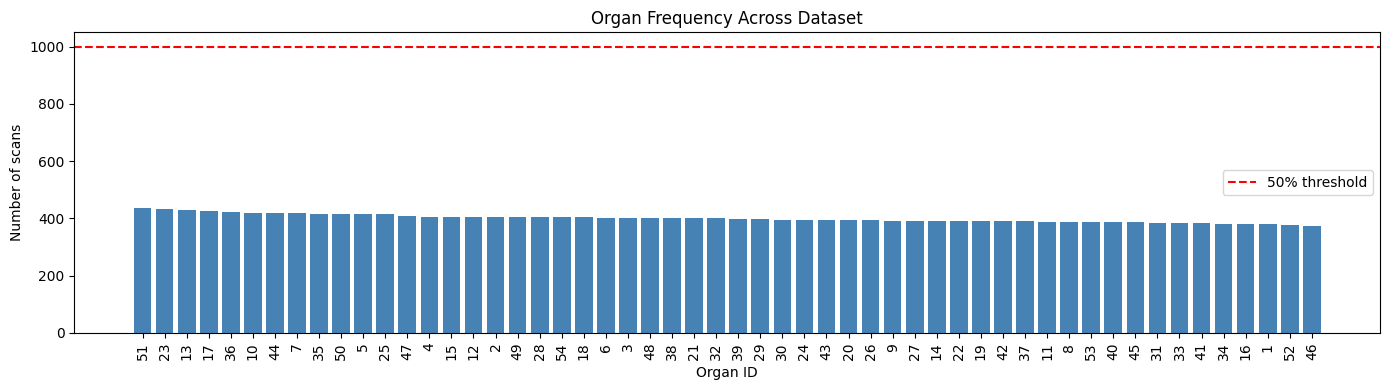

In [19]:
import matplotlib.pyplot as plt

freq = df_labels.sum().sort_values(ascending=False)
freq_pct = (freq / len(df_labels) * 100).round(1)

summary = pd.DataFrame({"count": freq, "present_in_%_of_scans": freq_pct})
display(summary)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(freq)), freq.values, color="steelblue")
ax.set_xticks(range(len(freq)))
ax.set_xticklabels(freq.index, rotation=90)
ax.set_xlabel("Organ ID")
ax.set_ylabel("Number of scans")
ax.set_title("Organ Frequency Across Dataset")
ax.axhline(len(df_labels) * 0.5, color="red", linestyle="--", label="50% threshold")
ax.legend()
plt.tight_layout()
plt.show()

## Labels per Image Distribution

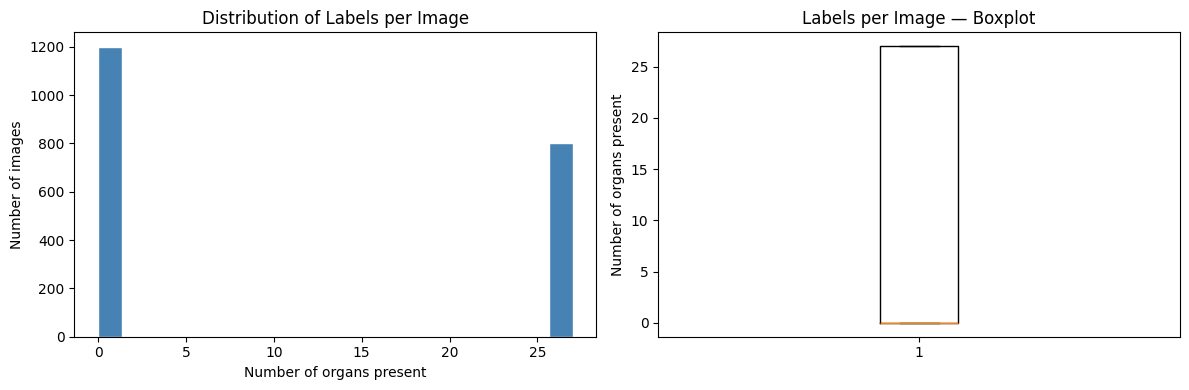

count    2000.0
mean       10.8
std        13.2
min         0.0
25%         0.0
50%         0.0
75%        27.0
max        27.0
dtype: float64


In [20]:
labels_per_image = df_labels.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(labels_per_image, bins=20, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Number of organs present")
axes[0].set_ylabel("Number of images")
axes[0].set_title("Distribution of Labels per Image")

axes[1].boxplot(labels_per_image, vert=True)
axes[1].set_ylabel("Number of organs present")
axes[1].set_title("Labels per Image — Boxplot")

plt.tight_layout()
plt.show()

print(labels_per_image.describe().round(1))

# Pixel-Level Class Imbalance Analysis (using y_train.csv)

The sections below use the actual segmentation labels — each pixel in the 256×256 mask is assigned one of 55 values (0 = background, 1–54 = organs). Data paths assume the dataset was unzipped at the repository root.

In [ ]:
import pandas as pd
import numpy as np
import cv2
from pathlib import Path

# Paths relative to this notebook's location (data unzipped one level up at repo root)
REPO_ROOT = Path("..").resolve()
TRAIN_DIR = REPO_ROOT / "train-images"
LABEL_CSV = REPO_ROOT / "y_train.csv"

# Load pixel-level labels (rows = pixels, columns = images → transpose to (N, H*W))
print("Loading y_train.csv — this takes ~20 s …")
labels_train = pd.read_csv(LABEL_CSV, index_col=0).T   # → (2000, 65536)
print(f"Labels shape: {labels_train.shape}  (images × pixels)")

# Load images in strict numerical order
def load_dataset(image_dir: Path) -> np.ndarray:
    files = sorted(Path(image_dir).glob("*.png"), key=lambda f: int(f.stem))
    return np.stack([cv2.imread(str(f), cv2.IMREAD_GRAYSCALE) for f in files], axis=0)

print("Loading train images …")
data_train = load_dataset(TRAIN_DIR)
print(f"Images shape: {data_train.shape}  (N × H × W)")

## Cell A — Class Frequency Audit

For each of the 54 organ classes, count how many training images contain at least one pixel of that class. Classes present in fewer than 50 images are highlighted in red.

In [ ]:
import matplotlib.pyplot as plt

NUM_CLASSES = 54
masks = labels_train.values.reshape(-1, 256, 256)  # (N, 256, 256)

# Count images containing each class
class_counts = {}
for cls in range(1, NUM_CLASSES + 1):
    class_counts[cls] = int(np.any(masks == cls, axis=(1, 2)).sum())

counts_series = pd.Series(class_counts).sort_values()
rare_threshold = 50
rare_classes = counts_series[counts_series < rare_threshold].index.tolist()

colors = ["red" if c < rare_threshold else "steelblue" for c in counts_series.values]

fig, ax = plt.subplots(figsize=(6, 14))
ax.barh(range(len(counts_series)), counts_series.values, color=colors)
ax.set_yticks(range(len(counts_series)))
ax.set_yticklabels([f"Class {i}" for i in counts_series.index])
ax.axvline(rare_threshold, color="red", linestyle="--", label=f"Threshold ({rare_threshold} images)")
ax.set_xlabel("Number of images containing class")
ax.set_title("Per-class image frequency (red = fewer than 50 images)")
ax.legend()
plt.tight_layout()
plt.show()

most_common_cls = counts_series.idxmax()
print(f"Rare classes (< {rare_threshold} images): {rare_classes}")
print(f"Most common class: Class {most_common_cls} ({counts_series[most_common_cls]} images)")

## Cell B — Resolution Experiment

Three example images that contain rare classes are shown at 256×256, 128×128, and 64×64 to evaluate how much structural detail is preserved at lower resolutions.

In [ ]:
def plot_slice_seg(ax_img, ax_seg, image, seg, title=""):
    """Show CT slice and its coloured mask side-by-side on provided axes."""
    ax_img.imshow(image, cmap="gray")
    ax_img.set_title(f"{title}\nCT")
    ax_img.axis("off")
    ax_seg.imshow(image, cmap="gray")
    seg_masked = np.ma.masked_where(seg == 0, seg)
    ax_seg.imshow(seg_masked, cmap="tab20", alpha=0.6, vmin=1, vmax=NUM_CLASSES)
    ax_seg.set_title(f"{title}\nMask")
    ax_seg.axis("off")

def downsample(img, size):
    return cv2.resize(img, (size, size), interpolation=cv2.INTER_NEAREST)

# Pick 3 images that contain at least one rare class
rare_image_indices = []
if rare_classes:
    rare_cls = rare_classes[0]  # use the rarest class
    for i in range(len(masks)):
        if np.any(masks[i] == rare_cls):
            rare_image_indices.append(i)
        if len(rare_image_indices) == 3:
            break

# Fallback: first 3 images if no rare class images found
if len(rare_image_indices) < 3:
    rare_image_indices = list(range(3))

resolutions = [256, 128, 64]
res_labels = ["256×256 (original)", "128×128", "64×64"]

fig, axes = plt.subplots(len(rare_image_indices), len(resolutions) * 2,
                         figsize=(4 * len(resolutions) * 2, 4 * len(rare_image_indices)))

for row, idx in enumerate(rare_image_indices):
    img = data_train[idx]
    seg = masks[idx]
    for col, (res, rlabel) in enumerate(zip(resolutions, res_labels)):
        img_r = downsample(img, res)
        seg_r = downsample(seg, res)
        plot_slice_seg(
            axes[row, col * 2],
            axes[row, col * 2 + 1],
            img_r, seg_r,
            title=f"Image {idx}\n{rlabel}"
        )

plt.suptitle("Resolution comparison: 256 vs 128 vs 64", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

At **128×128** anatomical structures are still clearly visible — major organs retain their shape and the colour overlay correctly follows organ boundaries. At **64×64** thin and tubular structures (vessels, bronchi, small intestine) collapse to single-pixel width or disappear entirely; only large, compact organs like liver and lungs remain identifiable. This means a model trained at 64×64 would likely ignore rare thin structures, so at minimum 128×128 should be used.

## Cell C — Training Subset Selection (Balanced)

To prevent the model from over-representing common anatomical structures and ignoring rare ones during training, we downsample the over-represented classes. For any class that appears in more than 2× the count of the rarest class, we randomly sample down to 2× the rarest count. The union of selected image indices forms a balanced training subset.

In [ ]:
import random
random.seed(42)
np.random.seed(42)

# Rarest class count
rarest_count = counts_series.min()
cap = int(2 * rarest_count)
print(f"Rarest class count: {rarest_count}  →  cap = {cap} images per class")

selected_indices = set()
original_counts = {}
selected_counts = {}

for cls in range(1, NUM_CLASSES + 1):
    cls_indices = np.where(np.any(masks == cls, axis=(1, 2)))[0].tolist()
    original_counts[cls] = len(cls_indices)
    if len(cls_indices) > cap:
        chosen = random.sample(cls_indices, cap)
    else:
        chosen = cls_indices
    selected_counts[cls] = len(chosen)
    selected_indices.update(chosen)

balanced_indices = np.array(sorted(selected_indices))

print(f"\nOriginal training set: {len(masks)} images")
print(f"Balanced subset:       {len(balanced_indices)} images")
print("\nClass | Original | Selected")
for cls in range(1, NUM_CLASSES + 1):
    flag = " ←" if original_counts[cls] > cap else ""
    print(f"  {cls:2d}  |  {original_counts[cls]:5d}   |  {selected_counts[cls]:5d}{flag}")

save_path = REPO_ROOT / "balanced_indices.npy"
np.save(save_path, balanced_indices)
print(f"\nSaved balanced_indices.npy → {save_path}")